In [1]:
import pickle 
import numpy as np
import matplotlib.pylab as pl
from itertools import zip_longest
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
from matplotlib.ticker import ScalarFormatter

/tmp/ipykernel_2926296/504229547.py:182: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axes[0].annotate("50N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_2926296/504229547.py:183: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axes[1].annotate("35N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_2926296/504229547.py:184: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axes[2].annotate("50N - Low intensity",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykern

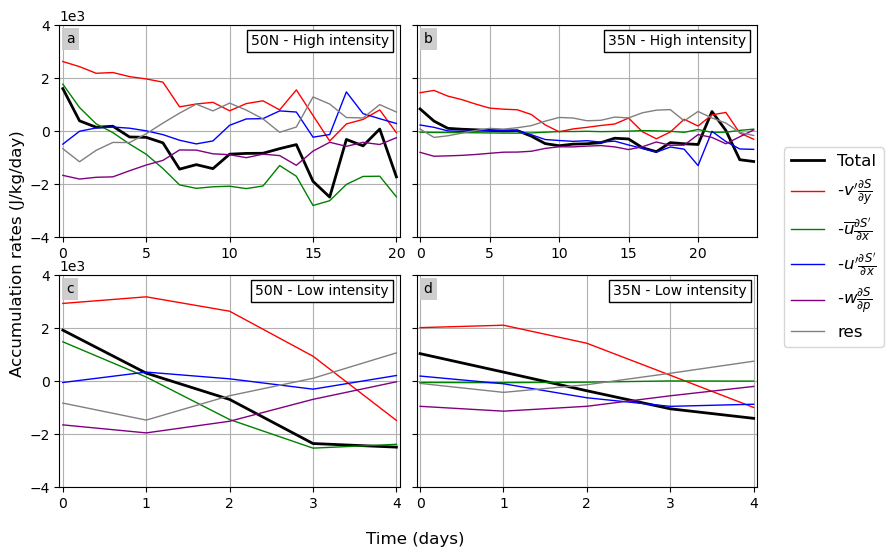

In [3]:
output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/long-run/'

with open(output_dir+'dse_rey_HD_50', 'rb') as f:
    rey_HD_50 = pickle.load(f)

with open(output_dir+'dse_rey_HD_35', 'rb') as f:
    rey_HD_35 = pickle.load(f)

with open(output_dir+'dse_rey_LD_50', 'rb') as f:
    rey_LD_50 = pickle.load(f)

with open(output_dir+'dse_rey_LD_35', 'rb') as f:
    rey_LD_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.18, wspace=0.05)
fig=pl.figure(figsize=(9,6))
axes = [pl.subplot(gs[0, 0]), 
       pl.subplot(gs[0, 1]), 
       pl.subplot(gs[1, 0]), 
       pl.subplot(gs[1, 1])]

ymin, ymax = -4000, 4000
labels = [
    'Total',
    r'-$v^\prime\frac{\partial S}{\partial y}$',
    r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
    r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
    r'-$w\frac{\partial S}{\partial p}$',
    'res'
]
######################## High duration 50 ##################################
dse_master=rey_HD_50
ax = axes[0]
x=[]

for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    sums, counts = [],[]

    for vals in zip_longest(*dse_master[d], fillvalue=np.nan):
        vals = np.array(vals)
        sums.append(np.nansum(vals))
        counts.append(np.sum(~np.isnan(vals)))

    x.append((np.array(sums)/np.array(counts)).tolist())
    
# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)

colors = ['black','red','green','blue','purple','grey']
for term,c,l in zip(x, colors, labels):
    if c =='black':
        ax.plot(np.arange(len(term[:])), term[:], color=c, lw=2, label=l)
    else:
        ax.plot(np.arange(len(term[:])), term[:], color=c, lw=1, label=l)

ax.set_ylim(ymin, ymax)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.yaxis.get_major_formatter()#.set_useMathText(True)
ax.margins(x=0.01)
ax.grid(True)
set_label(fig,ax, 'a')

######################## High duration 35 ##################################
dse_master=rey_HD_35
ax = axes[1]
x=[]

for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    sums, counts = [],[]

    for vals in zip_longest(*dse_master[d], fillvalue=np.nan):
        vals = np.array(vals)
        sums.append(np.nansum(vals))
        counts.append(np.sum(~np.isnan(vals)))

    x.append((np.array(sums)/np.array(counts)).tolist())
    
# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)

colors = ['black','red','green','blue','purple','grey']
for term,c in zip(x, colors):
    if c =='black':
        ax.plot(np.arange(len(term[:])), term[:], color=c, lw=2)
    else:
        ax.plot(np.arange(len(term[:])), term[:], color=c, lw=1)

ax.set_ylim(ymin, ymax)
#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#ax.yaxis.get_major_formatter()#.set_useMathText(True)
ax.set_yticklabels([])
ax.margins(x=0.01)
ax.grid(True)
set_label(fig,ax, 'b')

######################## Low duration 50 ##################################
dse_master=rey_LD_50
ax = axes[2]
x=[]

for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    sums, counts = [],[]

    for vals in zip_longest(*dse_master[d], fillvalue=np.nan):
        vals = np.array(vals)
        sums.append(np.nansum(vals))
        counts.append(np.sum(~np.isnan(vals)))

    x.append((np.array(sums)/np.array(counts)).tolist())
    
# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)

colors = ['black','red','green','blue','purple','grey']
for term,c in zip(x, colors):
    if c =='black':
        ax.plot(np.arange(len(term[:])), term[:], color=c, lw=2)
    else:
        ax.plot(np.arange(len(term[:])), term[:], color=c, lw=1)

ax.set_ylim(ymin, ymax)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.yaxis.get_major_formatter()#.set_useMathText(True)
ax.margins(x=0.01)
ax.grid(True)
set_label(fig,ax, 'c')

######################## Low duration 35 ##################################
dse_master=rey_LD_35
ax = axes[3]
x=[]

for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    sums, counts = [],[]

    for vals in zip_longest(*dse_master[d], fillvalue=np.nan):
        vals = np.array(vals)
        sums.append(np.nansum(vals))
        counts.append(np.sum(~np.isnan(vals)))

    x.append((np.array(sums)/np.array(counts)).tolist())
    
# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)

colors = ['black','red','green','blue','purple','grey']
for term,c in zip(x, colors):
    if c =='black':
        ax.plot(np.arange(len(term[:])), term[:], color=c, lw=2)
    else:
        ax.plot(np.arange(len(term[:])), term[:], color=c, lw=1)

ax.set_ylim(ymin, ymax)
#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#ax.yaxis.get_major_formatter()#.set_useMathText(True)
ax.set_yticklabels([])
ax.margins(x=0.01)
ax.grid(True)
set_label(fig,ax, 'd')


fig.legend(bbox_to_anchor=(1.05, 0.69), fontsize='large')
fig.supylabel("Accumulation rates (J/kg/day)", x=0.07)
fig.supxlabel('Time (days)', x=0.52)
axes[0].annotate("50N - High duration",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
axes[1].annotate("35N - High duration",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
axes[2].annotate("50N - Low duration",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
axes[3].annotate("35N - Low duration",xy=(0.575,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.savefig('5.pdf', bbox_inches='tight')
fig.savefig('5.jpg',dpi=600, bbox_inches='tight')

/tmp/ipykernel_874109/575499154.py:196: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axes[0].annotate("50N - High duration",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_874109/575499154.py:197: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axes[1].annotate("35N - High duration",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_874109/575499154.py:198: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axes[2].annotate("50N - Low duration",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_874

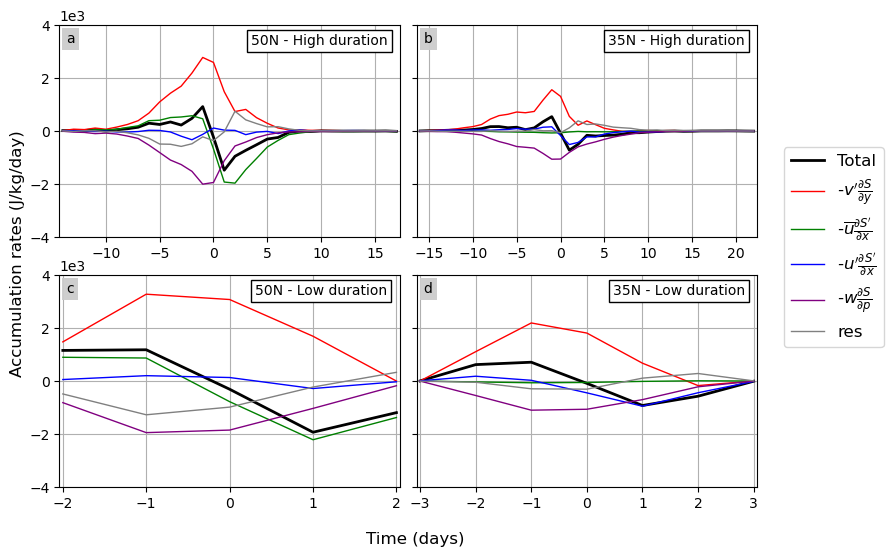

In [3]:
# heatwaves aligned with max intensity

output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/long-run/'

with open(output_dir+'dse_rey_HD_50', 'rb') as f:
    rey_HD_50 = pickle.load(f)

with open(output_dir+'dse_rey_HD_35', 'rb') as f:
    rey_HD_35 = pickle.load(f)

with open(output_dir+'dse_rey_LD_50', 'rb') as f:
    rey_LD_50 = pickle.load(f)

with open(output_dir+'dse_rey_LD_35', 'rb') as f:
    rey_LD_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

def align_max_intensity(dataset):
    #dataset = dse_master['dsetot']
    max_T = [avg_cons(i) for i in dse_master['T']]
    peaks = [np.argmax(T) for T in max_T]
    ref_peak = max(peaks)
    aligned = []
    for data, peak in zip(dataset, peaks):
        shift = ref_peak - peak
        padded = np.pad(data,(shift, 0), constant_values=0)
        aligned.append(padded)

    max_len = max(len(a) for a in aligned)
    aligned = [np.pad(a, (0, max_len-len(a)), constant_values=0) for a in aligned]

    aligned = np.array(aligned)

    mean = np.mean(aligned, axis=0)
    return mean, ref_peak

def time_axis(length, ref_peak):
    x = [0]*(length)
    start_val = -ref_peak
    for i in range(len(x)):
        x[i] = start_val
        start_val+=1
    return x

def avg_cons(x):
    x = np.array(x)
    return (x[1:]+x[:-1])/2


#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.18, wspace=0.05)
fig=pl.figure(figsize=(9,6))
axes = [pl.subplot(gs[0, 0]), 
       pl.subplot(gs[0, 1]), 
       pl.subplot(gs[1, 0]), 
       pl.subplot(gs[1, 1])]

ymin, ymax = -4000, 4000
labels = [
    'Total',
    r'-$v^\prime\frac{\partial S}{\partial y}$',
    r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
    r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
    r'-$w\frac{\partial S}{\partial p}$',
    'res'
]

######################## High duration 50 ##################################
dse_master=rey_HD_50
ax = axes[0]
x=[]

for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    mean, ref_peak = align_max_intensity(dse_master[d])
    x.append(mean)
    
    
# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)

colors = ['black','red','green','blue','purple','grey']
for term,c,l in zip(x, colors, labels):
    if c =='black':
        ax.plot(time_axis(len(term),ref_peak), term[:], color=c, lw=2, label=l)
    else:
        ax.plot(time_axis(len(term),ref_peak), term[:], color=c, lw=1, label=l)

ax.set_ylim(ymin, ymax)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.yaxis.get_major_formatter()#.set_useMathText(True)
ax.margins(x=0.01)
ax.grid(True)
set_label(fig,ax, 'a')

######################## High duration 35 ##################################
dse_master=rey_HD_35
ax = axes[1]
x=[]

for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    mean, ref_peak = align_max_intensity(dse_master[d])
    x.append(mean)
    
    
# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)

colors = ['black','red','green','blue','purple','grey']
for term,c in zip(x, colors):
    if c =='black':
        ax.plot(time_axis(len(term),ref_peak), term[:], color=c, lw=2)
    else:
        ax.plot(time_axis(len(term),ref_peak), term[:], color=c, lw=1)

ax.set_ylim(ymin, ymax)
#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#ax.yaxis.get_major_formatter()#.set_useMathText(True)
ax.set_yticklabels([])
ax.margins(x=0.01)
ax.grid(True)
set_label(fig,ax, 'b')

######################## Low duration 50 ##################################
dse_master=rey_LD_50
ax = axes[2]
x=[]

for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    mean, ref_peak = align_max_intensity(dse_master[d])
    x.append(mean)
    
    
# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)

colors = ['black','red','green','blue','purple','grey']
for term,c in zip(x, colors):
    if c =='black':
        ax.plot(time_axis(len(term),ref_peak), term[:], color=c, lw=2)
    else:
        ax.plot(time_axis(len(term),ref_peak), term[:], color=c, lw=1)

ax.set_ylim(ymin, ymax)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.yaxis.get_major_formatter()#.set_useMathText(True)
ax.margins(x=0.01)
ax.grid(True)
set_label(fig,ax, 'c')

######################## Low duration 35 ##################################
dse_master=rey_LD_35
ax = axes[3]
x=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    mean, ref_peak = align_max_intensity(dse_master[d])
    x.append(mean)
    
    
# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)

colors = ['black','red','green','blue','purple','grey']
for term,c in zip(x, colors):
    if c =='black':
        ax.plot(time_axis(len(term),ref_peak), term[:], color=c, lw=2)
    else:
        ax.plot(time_axis(len(term),ref_peak), term[:], color=c, lw=1)

ax.set_ylim(ymin, ymax)
#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#ax.yaxis.get_major_formatter()#.set_useMathText(True)
ax.set_yticklabels([])
ax.margins(x=0.01)
ax.grid(True)
set_label(fig,ax, 'd')


fig.legend(bbox_to_anchor=(1.05, 0.69), fontsize='large')
fig.supylabel("Accumulation rates (J/kg/day)", x=0.07)
fig.supxlabel('Time (days)', x=0.52)
axes[0].annotate("50N - High duration",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
axes[1].annotate("35N - High duration",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
axes[2].annotate("50N - Low duration",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
axes[3].annotate("35N - Low duration",xy=(0.575,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.savefig('5 modified.pdf', bbox_inches='tight')
fig.savefig('5 modified.jpg',dpi=600, bbox_inches='tight')